## Step 1: Settings and imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ----- Settings (change them here) -----
SEED = 42
SIZES = [2500, 5000]      # how many images to use
EPOCHS = [50, 100]        # how many epochs to train
LEARNING_RATE = 0.001     # Adam default; 0.01 was too high for an autoencoder
BATCH_SIZE = 64
OUTPUT_DIR = "output"      # CSV files are saved here
NOISE = 0.15              # noise strength, applied to the test set only


os.makedirs(OUTPUT_DIR, exist_ok=True)


def set_seed():
    """Make every run give the same result."""
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

## Step 2: Load MNIST

In [2]:
(x_a, y_a), (x_b, y_b) = tf.keras.datasets.mnist.load_data()
X = np.concatenate([x_a, x_b]).reshape(-1, 784) / 255.0   # flatten 28x28 -> 784, scale to 0..1
Y = np.concatenate([y_a, y_b])
print("Total images:", len(X))

Total images: 70000


## Step 3: Helper functions

Each function does one small job, so `run_experiment` is easy to read.

In [3]:
def build_autoencoder():
    """784 -> 512 -> 256 (bottleneck) -> 512 -> 784"""
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),      # encoder
        layers.Dense(256, activation="relu"),      # bottleneck
        layers.Dense(512, activation="relu"),      # decoder
        layers.Dense(784, activation="sigmoid"),   # output: 784 pixels
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss="mse", metrics=["mse", "mae"])
    return model


def build_classifier():
    """Small digit reader, used only to score the reconstructed images."""
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def split_data(size):
    """Pick `size` random images, then split 70% train / 20% test / 10% validation."""
    idx = np.random.RandomState(SEED).permutation(len(X))[:size]
    x, y = X[idx], Y[idx]
    x_train, x_rest, y_train, y_rest = train_test_split(x, y, train_size=0.70, random_state=SEED)
    x_test, x_val, y_test, y_val = train_test_split(x_rest, y_rest, train_size=2 / 3, random_state=SEED)
    return x_train, y_train, x_val, x_test, y_test


def add_noise(images):
    """Add Gaussian noise and keep pixels in 0..1."""
    noise = NOISE * np.random.RandomState(SEED).normal(size=images.shape)
    return np.clip(images + noise, 0, 1)


def plot_loss(history, title, extra=None, path=None):
    epochs_range = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Subplot 1: MSE curves (Train MSE, Val MSE, Test MSE)
    axes[0].plot(epochs_range, history.history["loss"], label="Train MSE", color="#1f77b4", lw=2)
    axes[0].plot(epochs_range, history.history["val_loss"], label="Val MSE", color="#ff7f0e", lw=2)
    if extra and "test_mse" in extra and len(extra["test_mse"]) == len(epochs_range):
        axes[0].plot(epochs_range, extra["test_mse"], label="Test MSE (noisy)", color="#2ca02c", linestyle="--", lw=2)
    axes[0].set_title("Loss / MSE over Epochs", fontsize=11)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (MSE)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend()

    # Subplot 2: MAE curves (Train MAE, Val MAE)
    if "mae" in history.history:
        axes[1].plot(epochs_range, history.history["mae"], label="Train MAE", color="#1f77b4", lw=2)
        axes[1].plot(epochs_range, history.history["val_mae"], label="Val MAE", color="#ff7f0e", lw=2)
        axes[1].set_title("Mean Absolute Error (MAE) over Epochs", fontsize=11)
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].grid(True, linestyle=":", alpha=0.6)
        axes[1].legend()

    fig.suptitle(title, fontsize=12, y=1.02)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_examples(original, noisy, result, n=6, path=None):
    fig, axes = plt.subplots(n, 3, figsize=(4.5, 1.4 * n))
    columns = [("Original", original), ("Test (noisy)", noisy), ("Result", result)]
    for row in range(n):
        for col, (name, images) in enumerate(columns):
            axes[row, col].imshow(images[row].reshape(28, 28), cmap="gray")
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(name, fontsize=10, fontweight="bold")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_ten_digits(original, noisy, result, y_true, y_pred, path):
    """Save one example of each digit 0-9: Original | Test (noisy) | Result (reconstruction).
    The Result title is the digit read from the reconstruction (green = correct, red = wrong)."""
    fig, axes = plt.subplots(10, 3, figsize=(4, 14))
    for digit in range(10):
        i = int(np.where(y_true == digit)[0][0])          # first test image of this digit
        ok = y_pred[i] == y_true[i]
        panels = [(original[i], "Original" if digit == 0 else "", "black"),
                  (noisy[i], "Test" if digit == 0 else "", "black"),
                  (result[i], f"Read as: {y_pred[i]}", "green" if ok else "red")]
        for col, (img, title, color) in enumerate(panels):
            axes[digit, col].imshow(img.reshape(28, 28), cmap="gray")
            axes[digit, col].axis("off")
            axes[digit, col].set_title(title, fontsize=9, color=color)
    fig.suptitle("Result of 10 digits", y=0.995)
    fig.tight_layout()
    fig.savefig(path, dpi=100)
    plt.close(fig)


def plot_confusion(y_true, y_pred, path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot(cmap="Blues", ax=ax)
    ax.set_title("Confusion matrix (digits read from reconstructed images)", fontsize=10)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Step 4: One experiment

split -> add noise to test set -> train -> reconstruct -> plot -> return numbers

In [4]:
def run_experiment(size, epochs):
    print(f"===== Size = {size}, Epochs = {epochs} =====")
    set_seed()

    x_train, y_train, x_val, x_test, y_test = split_data(size)
    x_test_noisy = add_noise(x_test)

    # Train: input = output = clean image
    model = build_autoencoder()
    # Record extra per-epoch numbers: noisy-test MSE and time taken
    extra = {"test_mse": [], "time": []}

    class EpochLogger(tf.keras.callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            self.start = time.time()

        def on_epoch_end(self, epoch, logs=None):
            extra["time"].append(time.time() - self.start)
            pred = self.model(x_test_noisy, training=False).numpy()
            extra["test_mse"].append(float(np.mean((pred - x_test) ** 2)))

    history = model.fit(x_train, x_train, validation_data=(x_val, x_val),
                        epochs=epochs, batch_size=BATCH_SIZE, verbose=0,
                        callbacks=[EpochLogger()])

    # Save the loss and metrics of every epoch to a CSV file
    train_mse = history.history.get("mse", history.history["loss"])
    val_mse = history.history.get("val_mse", history.history["val_loss"])
    epoch_table = pd.DataFrame({
        "Epoch": range(1, epochs + 1),
        "Train Loss": history.history["loss"],
        "Val Loss": history.history["val_loss"],
        "Train MSE": train_mse,
        "Val MSE": val_mse,
        "Train MAE": history.history["mae"],
        "Val MAE": history.history["val_mae"],
        "Test MSE": extra["test_mse"],
        "Loss Gap (Val-Train)": np.array(history.history["val_loss"]) - np.array(history.history["loss"]),
        "Epoch Time (s)": extra["time"],
    })
    epoch_table.to_csv(f"{OUTPUT_DIR}/epochs_size{size}_epochs{epochs}.csv", index=False)

    # Reconstruct the noisy test images and compare with the clean originals
    result = model.predict(x_test_noisy, verbose=0)
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]
    train_mae = history.history["mae"][-1]
    val_mae = history.history["val_mae"][-1]
    test_mse = float(np.mean((result - x_test) ** 2))

    # Classify the reconstructions to build the confusion matrix
    classifier = build_classifier()
    classifier.fit(x_train, y_train, epochs=10, verbose=0)
    y_pred = classifier.predict(result, verbose=0).argmax(axis=1)
    accuracy = float(np.mean(y_pred == y_test))

    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | "
          f"Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | "
          f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
          f"Test MSE: {test_mse:.4f} | Digit accuracy: {accuracy:.2%}")

    # Plot and save graphs of training curves, sample reconstructions, and confusion matrix
    plot_loss(
        history,
        title=f"Training vs Validation Loss & MSE (size={size}, epochs={epochs})",
        extra=extra,
        path=f"{OUTPUT_DIR}/graph_loss_size{size}_epochs{epochs}.png"
    )
    plot_examples(
        x_test, x_test_noisy, result,
        path=f"{OUTPUT_DIR}/graph_samples_size{size}_epochs{epochs}.png"
    )
    plot_confusion(
        y_test, y_pred,
        path=f"{OUTPUT_DIR}/graph_confusion_size{size}_epochs{epochs}.png"
    )
    save_ten_digits(
        x_test, x_test_noisy, result, y_test, y_pred,
        f"{OUTPUT_DIR}/result_10_digits_size{size}_epochs{epochs}.png"
    )

    return {
        "Size": size,
        "Epochs": epochs,
        "Train Loss": train_loss,
        "Val Loss": val_loss,
        "Train MSE": train_loss,
        "Val MSE": val_loss,
        "Train MAE": train_mae,
        "Val MAE": val_mae,
        "Test MSE": test_mse,
        "Digit Accuracy": accuracy
    }


## Step 5: Run all 4 experiments

===== Size = 2500, Epochs = 50 =====
Train loss: 0.0054 | Val loss: 0.0096 | Train MSE: 0.0054 | Val MSE: 0.0096 | Train MAE: 0.0234 | Val MAE: 0.0314 | Test MSE: 0.0124 | Digit accuracy: 87.00%


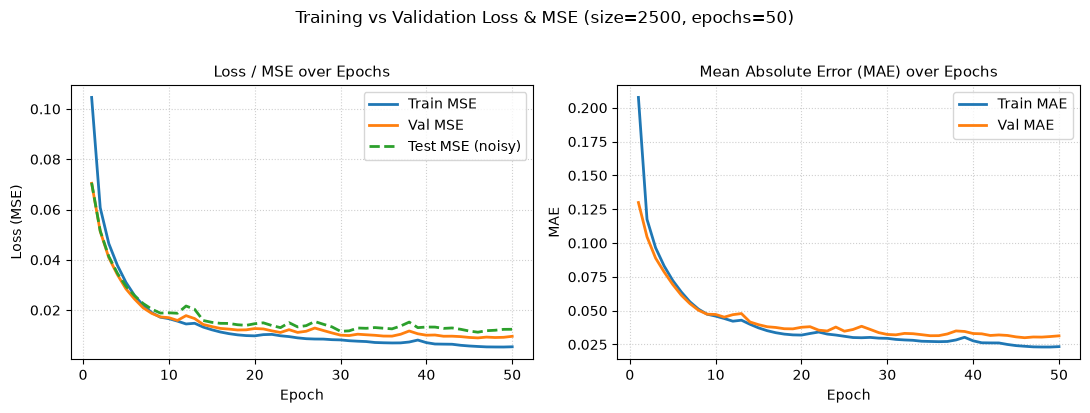

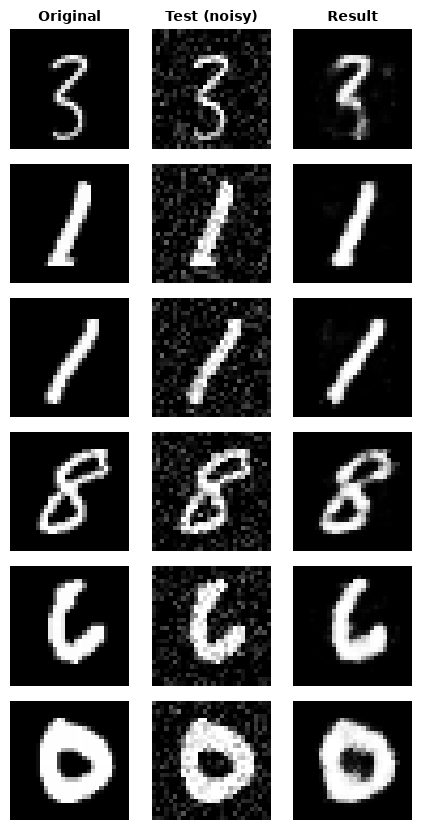

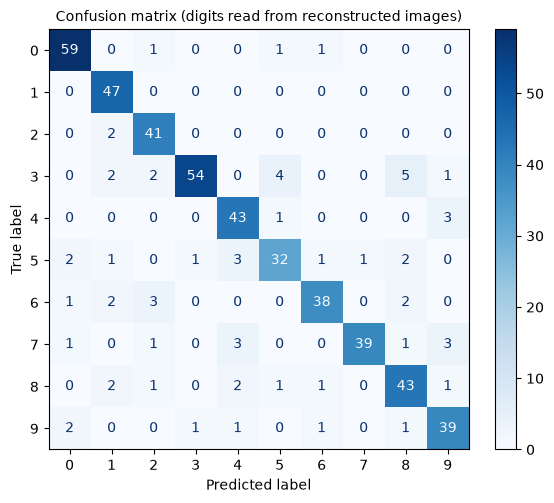

===== Size = 2500, Epochs = 100 =====
Train loss: 0.0033 | Val loss: 0.0100 | Train MSE: 0.0033 | Val MSE: 0.0100 | Train MAE: 0.0192 | Val MAE: 0.0311 | Test MSE: 0.0135 | Digit accuracy: 87.60%


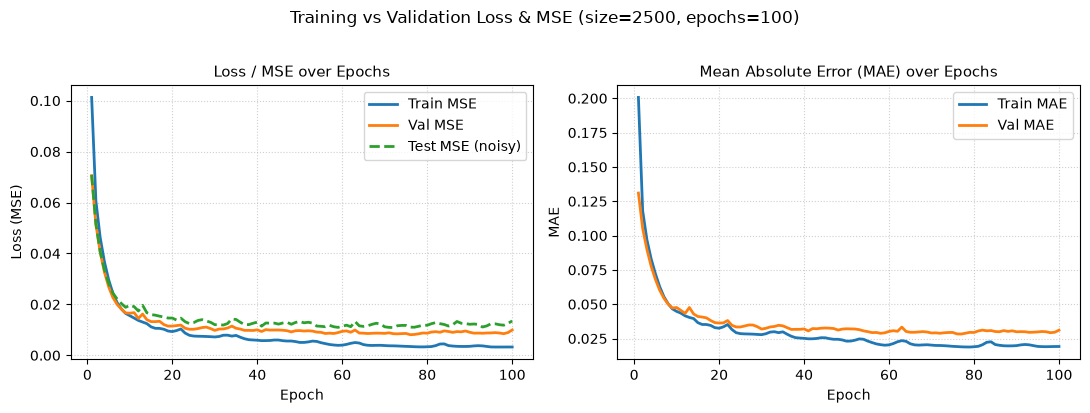

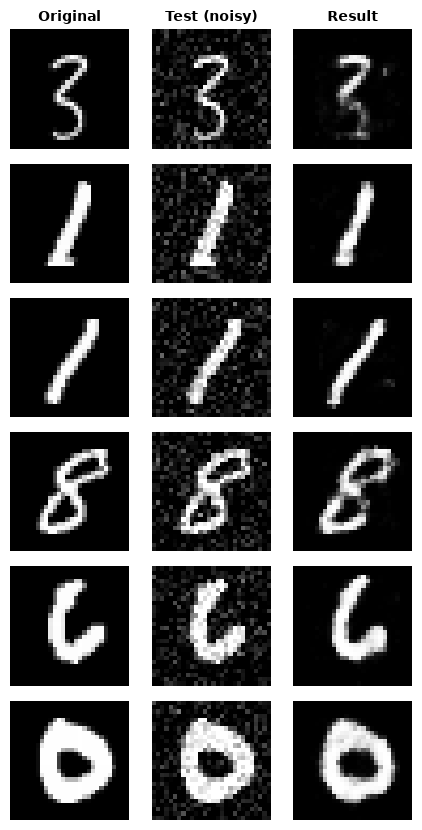

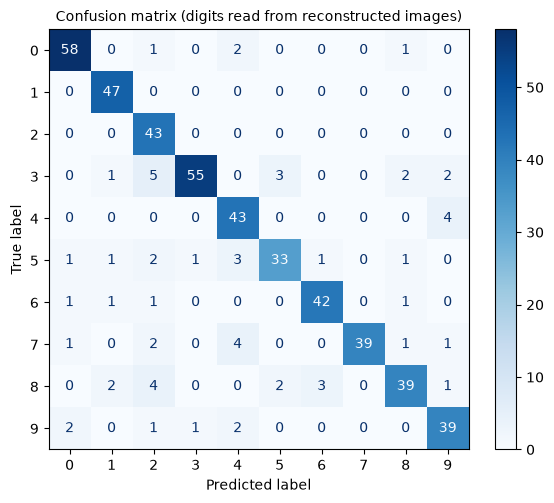

===== Size = 5000, Epochs = 50 =====
Train loss: 0.0045 | Val loss: 0.0078 | Train MSE: 0.0045 | Val MSE: 0.0078 | Train MAE: 0.0215 | Val MAE: 0.0286 | Test MSE: 0.0109 | Digit accuracy: 92.90%


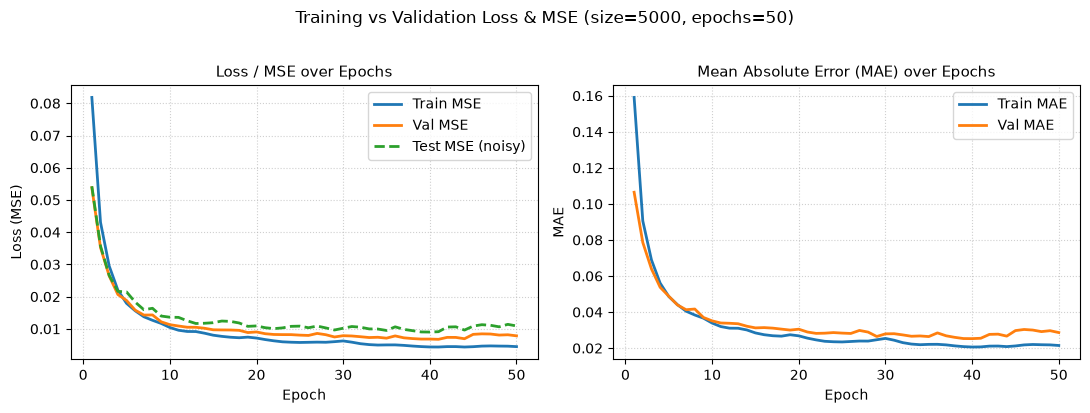

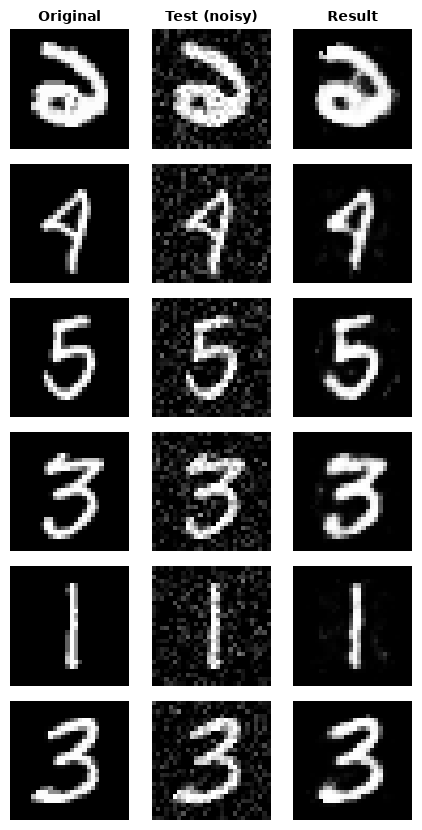

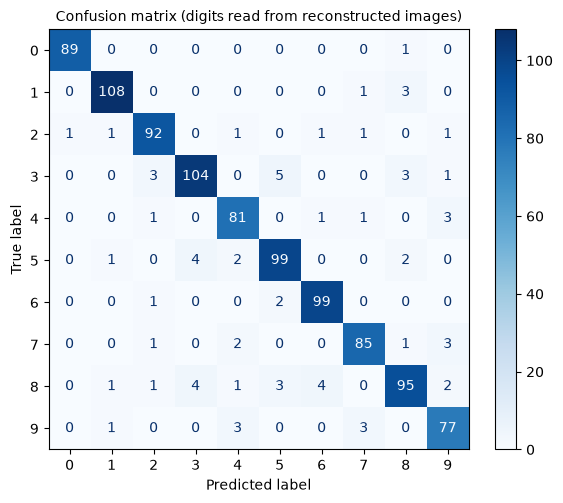

===== Size = 5000, Epochs = 100 =====
Train loss: 0.0030 | Val loss: 0.0070 | Train MSE: 0.0030 | Val MSE: 0.0070 | Train MAE: 0.0185 | Val MAE: 0.0262 | Test MSE: 0.0104 | Digit accuracy: 91.80%


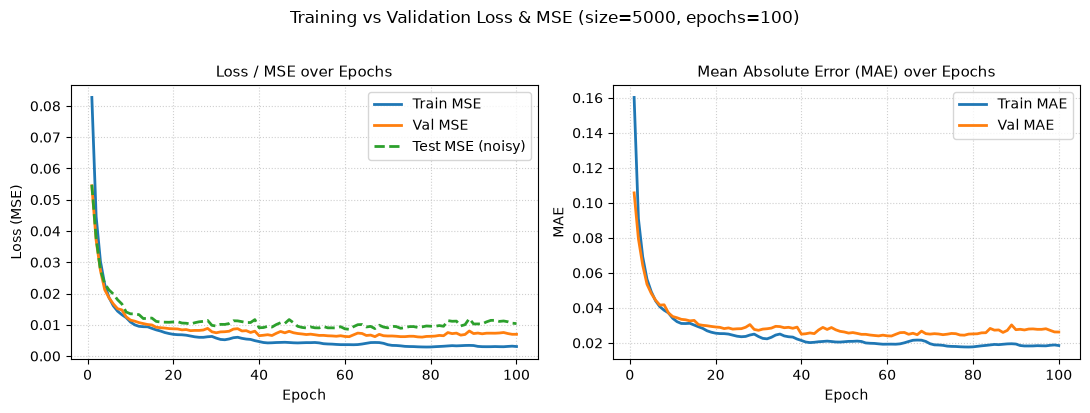

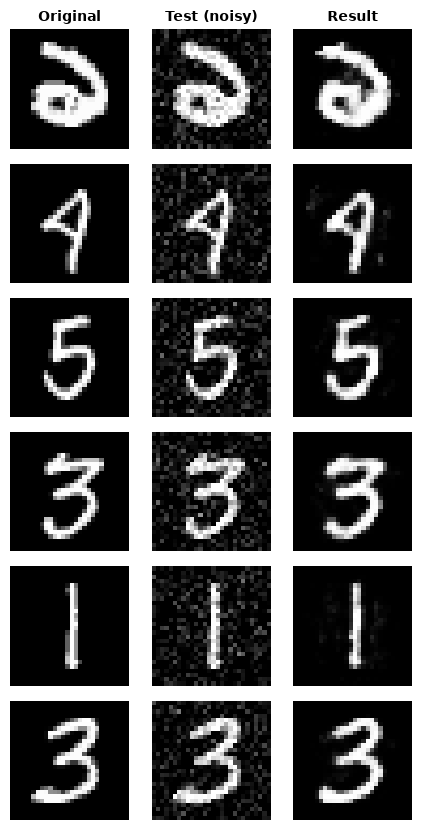

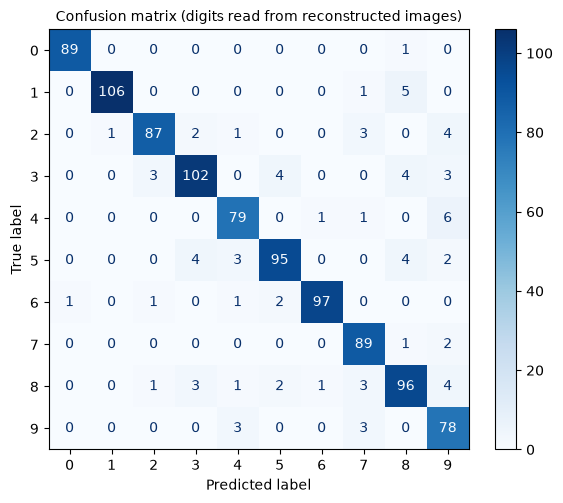

In [5]:
results = [run_experiment(size, epochs) for size in SIZES for epochs in EPOCHS]

## Summary table

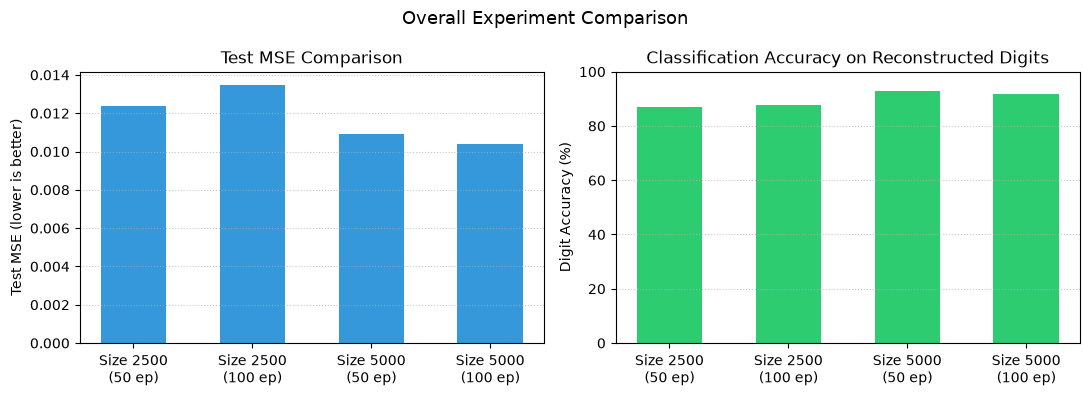

,Size,Epochs,Train Loss,Val Loss,Train MSE,Val MSE,Train MAE,Val MAE,Test MSE,Digit Accuracy
0,2500,50,0.0054,0.0096,0.0054,0.0096,0.0234,0.0314,0.0124,0.870
1,2500,100,0.0033,0.0100,0.0033,0.0100,0.0192,0.0311,0.0135,0.876
2,5000,50,0.0045,0.0078,0.0045,0.0078,0.0215,0.0286,0.0109,0.929
3,5000,100,0.0030,0.0070,0.0030,0.0070,0.0185,0.0262,0.0104,0.918


In [6]:
summary = pd.DataFrame(results).round(4)
summary.to_csv(f"{OUTPUT_DIR}/results.csv", index=False)

# Comparison graph across all configurations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
labels = [f"Size {r['Size']}\n({r['Epochs']} ep)" for r in results]
x_pos = np.arange(len(labels))

# Test MSE comparison
ax1.bar(x_pos, [r['Test MSE'] for r in results], color='#3498db', width=0.55)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Test MSE (lower is better)")
ax1.set_title("Test MSE Comparison")
ax1.grid(axis='y', linestyle=':', alpha=0.7)

# Digit Accuracy comparison
ax2.bar(x_pos, [r['Digit Accuracy'] * 100 for r in results], color='#2ecc71', width=0.55)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Digit Accuracy (%)")
ax2.set_title("Classification Accuracy on Reconstructed Digits")
ax2.set_ylim(0, 100)
ax2.grid(axis='y', linestyle=':', alpha=0.7)

fig.suptitle("Overall Experiment Comparison", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/graph_summary_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

summary
